In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import torch
import numpy as np
from SMT import *
import torchaudio
from kmeans import *
from ctc import *
from smtlstm import *
from smt_accumulator import *
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
librispeech_ds = torchaudio.datasets.LIBRISPEECH(
    root=str("/mnt/data/SMT"), url="train-clean-100", download=True,
)

In [3]:
total_samples = 2000
sample = torch.randperm(len(librispeech_ds))[:total_samples]
sample_ds = [librispeech_ds[idx] for idx in sample]


In [4]:
audio_features = extract_features_from_dataset(sample_ds, 
                                                len(sample_ds), 
                                                20,
                                                window_ms=10, hop_ms=5)

# this is kinda stupid, just do this in the previous function
mels = [clip["mel_spectrogram"] for _, clip in audio_features.items()]
mfccs = [clip["mfcc"] for _, clip in audio_features.items()]
log_mels = [clip["log_mel_db"] for _, clip in audio_features.items()]
text = [clip['text'] for _, clip in audio_features.items()]

hop_length = [clip["hop_length"] for _, clip in audio_features.items()][0]
sr = [clip["sr"] for _, clip in audio_features.items()][0]

# patch and preprocess
patches, utterance_bounds = patch_multiple_utterances(log_mels, sr, hop_length, 50, patch_frame_hop=1)
norm_patches, mean, std, zcaMatrix = preprocess_patches(patches)

# save everything
np.save("/mnt/data/SMT/norm_patches.npy", norm_patches)
np.save("/mnt/data/SMT/text.npy", text)
np.save("/mnt/data/SMT/utterance_bounds.npy", utterance_bounds)
np.save("/mnt/data/SMT/mean.npy", mean)
np.save("/mnt/data/SMT/std.npy", std)
np.save("/mnt/data/SMT/zcaMatrix.npy", zcaMatrix)

log_mel extraction:   0%|          | 0/2000 [00:00<?, ?it/s]

patching: 100%|██████████| 2000/2000 [00:07<00:00, 258.64it/s]


normalize patches
zca patches


In [ ]:
kmeans = apply_kmeans_to_patches(norm_patches, 3000, None)
centroids = torch.tensor(kmeans.cluster_centers_).to(device)

Init 1/3 with method k-means++


KeyboardInterrupt: 

In [5]:
# kmeans for sparse coding
labels, centroids, inertia, counts = minibatch_kmeans_gpu_vectorized(
    norm_patches,
    n_clusters=3000,
    batch_size=8000,
    n_iters=1000,
    n_init=3,
    distance="euclidean",
    init="random",
    reassignment_ratio=0.01,
    reassignment_freq=25,
    final_reassign=True,
    final_batch_size=8000,
    verbose=False,
)
np.save('/mnt/data/SMT/clusters.npy', centroids.cpu().numpy())

In [2]:
norm_patches = np.load("/mnt/data/SMT/norm_patches.npy")
utterance_bounds = np.load("/mnt/data/SMT/utterance_bounds.npy")
mean = np.load("/mnt/data/SMT/mean.npy")
std = np.load("/mnt/data/SMT/std.npy")
zcaMatrix = np.load("/mnt/data/SMT/zcaMatrix.npy")

centroids = np.load('/mnt/data/SMT/clusters.npy')
centroids = torch.tensor(centroids).to(device)

In [3]:
accumulator = DenseKSparseSMTAccumulator(centroids,
                                         K=16,
                                         batch_size=100,
                                         enforce_positive_coefficients=True,
                                         normalize_dictionary=True,
                                         FISTA_Iters=1000,
                                         diff_order="second",
                                         device=device,
                                         dtype=torch.float32,
                                         center_codes=False)
accumulator.batch_process_patches(torch.tensor(norm_patches), utterance_bounds)

100%|██████████| 1000/1000 [02:29<00:00,  6.70it/s]
/home/zbalkhy/EEC289/final_project/smt_accumulator.py:182: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.sparse_codes_per_batch.append(A.cpu().to_sparse_csr())
100%|██████████| 20/20 [49:05<00:00, 147.27s/it]


In [4]:
smt_stats = accumulator.finalize()
sparse_codes = torch.cat([batch.to_dense() for batch in accumulator.sparse_codes_per_batch])

torch.save(smt_stats, "/mnt/data/SMT/smt_stats_2000.pt")
torch.save(sparse_codes, '/mnt/data/SMT/sparse_codes_2000.pt')

In [5]:
print(sparse_codes.shape)
print(norm_patches.shape)

torch.Size([613964, 3000])
(613964, 160)


In [5]:
values, indices = torch.topk(sparse_codes.sum(0), 100)

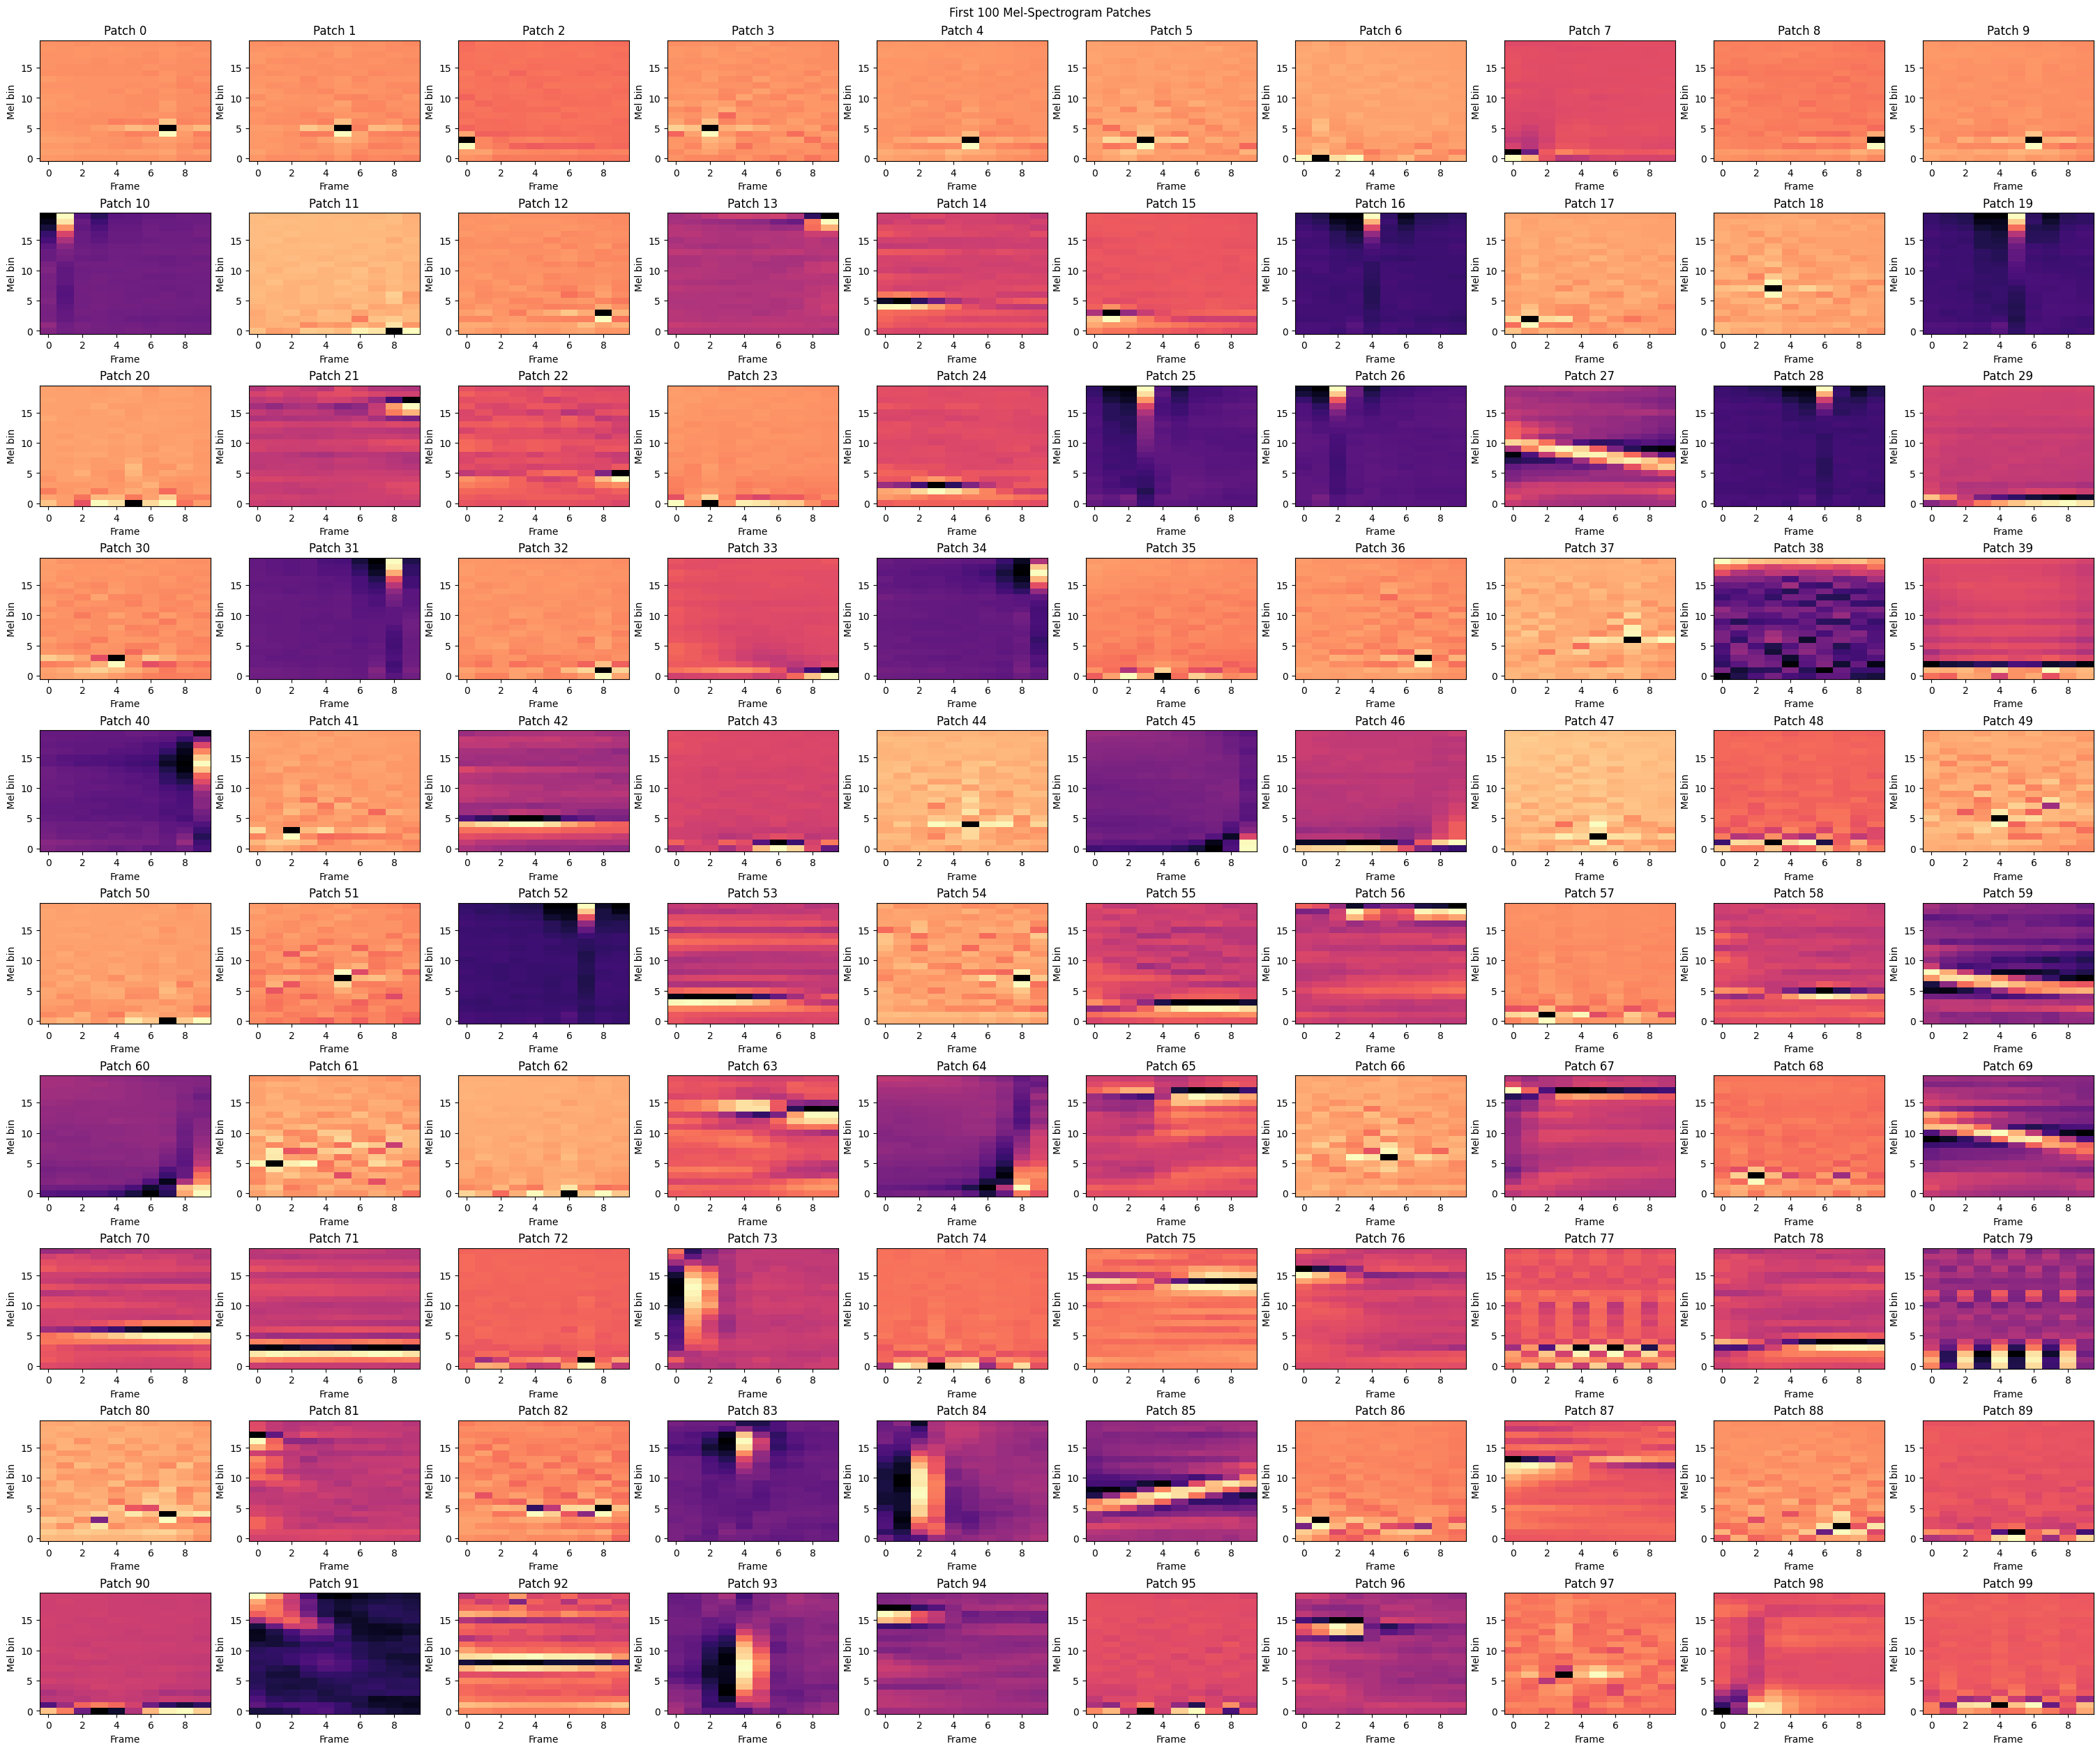

In [7]:
plot_first_n_mel_patches(centroids[indices,:].cpu().reshape(centroids[indices,:].shape[0], 20, 10), 100, cols=10)

In [9]:
from kmeans_diagnostics import *

diag = run_dictionary_diagnostics(
    patches=norm_patches,         # (N, D)
    dictionary=centroids.cpu(),        # (K, D)
    codes=sparse_codes.cpu(),                  # (N, K)
    patch_shape=(20, 10),
    energy_mode="rms",
    top_k_plot=100
)

KeyboardInterrupt: 

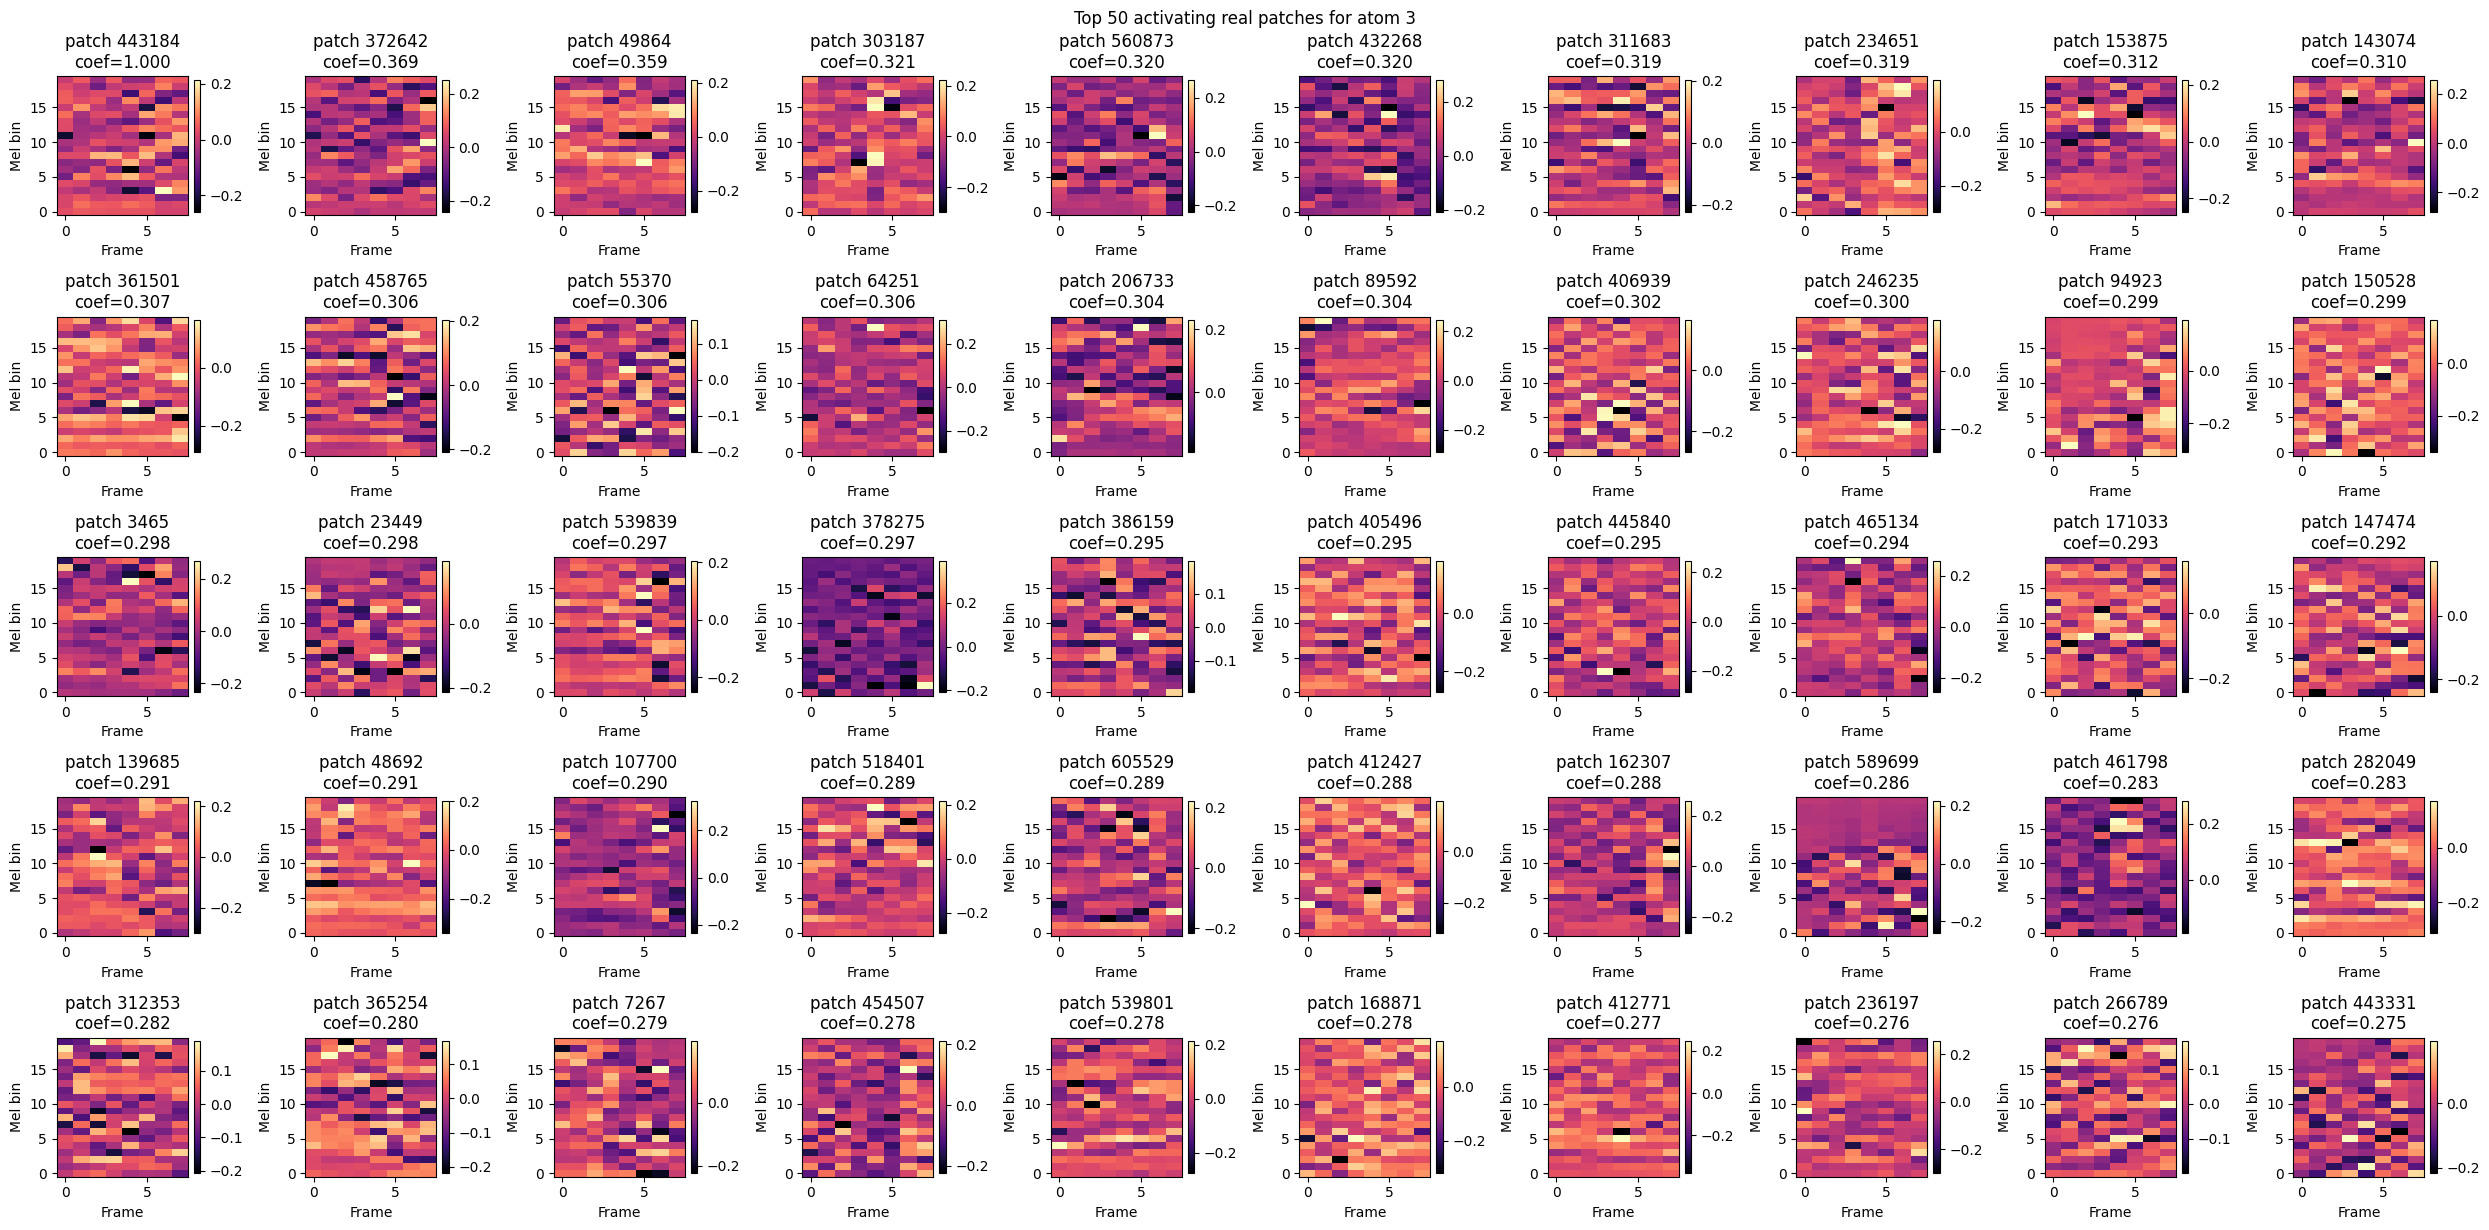

In [33]:
# "low_energy_atom": low_energy_atom,
# "edge_atom": edge_atom,
# "boundary_atom": boundary_atom,
# "silence_like_atom": silence_like_atom,
# "suspicious": suspicious,
sus = np.where(diag["flags"]["suspicious"])[0]
atom_idx = int(sus[3])

plot_top_activating_patches_for_atom(
    atom_idx=atom_idx,
    patches=norm_patches[:sparse_codes.shape[0],:],
    codes=sparse_codes.cpu(),
    patch_shape=(20, 8),   # omit if patches are already (N,H,W)
    top_n=50,
    cols=10
)

In [ ]:
eigvals, eigvecs = spectral_decomp_dense_second_order_torch(sparse_codes, utterance_bounds)

# take smallest d eigenvectors as P
d=256
P = eigvecs[:, 1:d+1].T

beta = P@sparse_codes.T
norm_beta, _, _ = preprocess_patches(beta.T.cpu().numpy()) # this switches beta to be NxD like norm_patches
norm_beta = norm_beta


In [ ]:
smt_stats, mel_stats = calc_metrics_per_utterance(norm_patches, norm_beta, utterance_bounds, 6)

In [ ]:
plot_paired_comparison(mel_stats['z_score_linear'], smt_stats['z_score_linear'], 80, 'curvature z_score', 'less')

In [ ]:
plot_paired_comparison(mel_stats['path_efficiency'], smt_stats['path_efficiency'], 80, 'path_efficiency', 'greater')

In [ ]:
(start, end) = utterance_bounds[0]
norm_beta[start:end].shape

plt.imshow(norm_beta[start:end].T, origin='lower', aspect='auto', cmap="magma")

In [ ]:
plt.imshow(sparse_codes[start:end,indices].cpu().numpy().T, origin='lower', aspect='auto', cmap="magma")

In [ ]:
import re
from g2p_en import G2p


def make_dataloader(dataset, tokenizer, batch_size=16, shuffle=True, num_workers=0):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=lambda batch: ctc_collate_fn(batch, tokenizer),
    )

class NormBetaDataset(Dataset):
    """Simple utterance-level dataset built from norm_beta and utterance bounds."""
    def __init__(self, norm_beta: np.ndarray, utterance_bounds, texts=None):
        self.norm_beta = norm_beta
        self.utterance_bounds = list(utterance_bounds)
        self.g2p = G2p()
        if texts is None:
            self.texts = [""] * len(self.utterance_bounds)
        else:
            if len(texts) != len(self.utterance_bounds):
                raise ValueError("texts must match utterance_bounds length")
            self.texts = list(texts)

    def __len__(self):
        return len(self.utterance_bounds)

    def __getitem__(self, idx):
        start, end = self.utterance_bounds[idx]
        x = torch.as_tensor(self.norm_beta[start:end, :], dtype=torch.float32)
        return {
            "features": x,
            "text": self._text_to_phonemes(self.texts[idx]),
        }
    
    def _text_to_phonemes(self, text, remove_stress=True):
        phonemes = self.g2p(text)

        # remove spaces/punctuation tokens
        phonemes = [p for p in phonemes if p.strip()]

        if remove_stress:
            phonemes = [p.rstrip("012") for p in phonemes]

        return phonemes

texts = [re.sub(r"[^a-z0-9\s]", "", librispeech_ds.get_metadata(idx)[2].lower()) for idx in range(len(utterance_bounds))]

data_length = len(utterance_bounds)
train_split =int(data_length*0.8)
train_bounds = utterance_bounds[:train_split]
train_text = texts[:train_split]
val_bounds = utterance_bounds[train_split:]
val_text = texts[train_split:]
train_dataset = NormBetaDataset(norm_beta, train_bounds, train_text)
val_dataset = NormBetaDataset(norm_beta, val_bounds, val_text)

PHONEMES = [
'AA','AE','AH','AO','AW','AY','EH','ER','EY','IH','IY',
'OW','OY','UH','UW',
'P','B','T','D','K','G',
'CH','JH',
'F','V','TH','DH','S','Z','SH','ZH','HH',
'M','N','NG',
'L','R','W','Y'
]
tokenizer = CharTokenizer()
train_loader = make_dataloader(train_dataset, tokenizer, batch_size=40, shuffle=True)
val_loader = make_dataloader(val_dataset, tokenizer, batch_size=40, shuffle=False)

# Infer input dimension from one sample
sample = train_dataset[0]["features"]
d_in = sample.shape[1]

model = SMTCTCBiLSTM(
    d_in=d_in,
    vocab_size=tokenizer.vocab_size,
    hidden_size=256,
    dropout=0.1,
    use_layernorm=True,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_state = train_ctc_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    tokenizer=tokenizer,
    device=device,
    num_epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    grad_clip_norm=5.0,
)

if best_state is not None:
    torch.save(best_state, "best_smt_ctc_linear.pt")
    print(f"Saved best checkpoint with val CER={best_state['val_cer']:.4f}")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = CharTokenizer(alphabet=PHONEMES, phonemes=True)

model = load_trained_bilstm_model(
    checkpoint_path="best_smt_ctc_linear.pt",
    d_in=d_in,
    vocab_size=tokenizer.vocab_size,
    device=device,
)

for sample in val_dataset:


    pred = predict_one(
        model=model,
        features=sample["features"],
        tokenizer=tokenizer,
        device=device,
        return_confidence=True,
    )

    print("Reference :", sample["text"])
    print("Predicted :", pred["text"])
    print("Confidence:", pred["confidence"])